### Use this script to identify other cutoffs for aging

In [1]:
import pandas as pd 
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from collections import Counter
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
plots_dir = "metadata_plots/"

In [3]:
metadata = pd.read_csv("01_donor_level_metadata.csv", index_col = 0)

In [4]:
metadata.shape

(299, 10)

### Examine number of donors by age group and sex

In [5]:
metadata.groupby(['age_group', 'sex']).size()

age_group  sex   
fetal      female     8
           male       5
middle     female    47
           male      81
old        female    38
           male      63
young      female    18
           male      39
dtype: int64

#### Check if the old has higher female representation, since it could explain why XIST increases with age?

In [6]:
contingency_table = pd.DataFrame({
    'female': [18, 38],
    'male':   [39, 63]  # 57-18 and 101-38
}, index=['Young (<40)', 'Old (>=40)'])

young_female_pct = 18 / 57 * 100
old_female_pct = 38 / 101 * 100
print(f"Young female: {young_female_pct:.1f}%")
print(f"Old female: {old_female_pct:.1f}%")

# perform chi-square
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"P-value for the chi-squared test is:, {chi2}")

Young female: 31.6%
Old female: 37.6%
P-value for the chi-squared test is:, 0.3476780064118756


### Examine the tertiles for aging analysis

In [7]:
postnatal_ages = list(metadata[metadata['age_status'] != "fetal"]['age'])
len(postnatal_ages)

286

In [8]:
postnatal_ages = [float(x) for x in postnatal_ages]

# calculate tertiles
tertiles = np.percentile(postnatal_ages, [33.3, 66.6])
print(f"Lower tertile (33.3%): {tertiles[0]:.2f}")
print(f"Upper tertile (66.6%): {tertiles[1]:.2f}")

lower_tertile, upper_tertile = tertiles

Lower tertile (33.3%): 46.00
Upper tertile (66.6%): 60.81


### Perform k-means approach

In [9]:
# reshape the ages to numpy array
postnatal_ages = np.array(postnatal_ages, dtype=float).reshape(-1, 1)

# perform k-means clustering
# use k=3 for 3 ages groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(postnatal_ages)

# add cluster labels back to original ages
age_df = pd.DataFrame({'age': postnatal_ages.flatten(), 'cluster': clusters})
age_df_sorted = age_df.sort_values('age')

/mnt/data1/william/tmp/ipykernel_1193786/2677359823.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=age_df, x='cluster_label', y='age', palette='viridis', jitter=True, alpha=0.7)


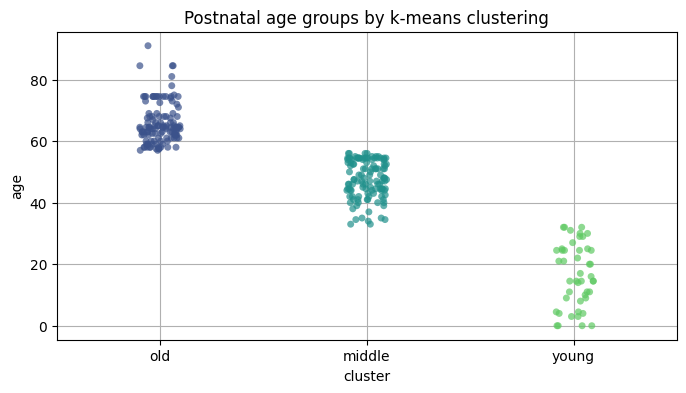

In [10]:
# assign clusters based on the age ranges
centers = kmeans.cluster_centers_.flatten()
cluster_order = np.argsort(centers)

# add the cluster labels to df
cluster_labels = {cluster_order[0]: 'young', cluster_order[1]: 'middle', cluster_order[2]: 'old'}
age_df['cluster_label'] = age_df['cluster'].map(cluster_labels)

# produce plot
plt.figure(figsize=(8, 4))
sns.stripplot(data=age_df, x='cluster_label', y='age', palette='viridis', jitter=True, alpha=0.7)
plt.title('Postnatal age groups by k-means clustering')
plt.xlabel('cluster')
plt.ylabel('age')
plt.grid(True)
plt.show()

In [11]:
# identify the age breakdowns for each cluster
min_mid_age = age_df[age_df['cluster_label'] == "middle"]['age'].min()
print(f"Max age for young: {min_mid_age}")

max_mid_age = age_df[age_df['cluster_label'] == "old"]['age'].min()
print(f"Max age for middle: {max_mid_age}")

Max age for young: 33.0
Max age for middle: 57.0


### Show three histograms comparing different age breakdowns

- Tertiles
- Using decades
- k-means

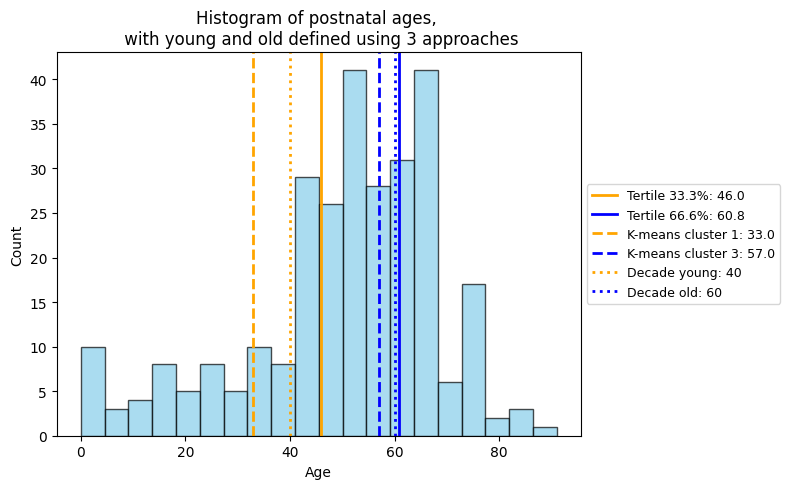

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(postnatal_ages, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# tertiles
plt.axvline(lower_tertile, color='orange', linestyle='-', linewidth=2, label=f'Tertile 33.3%: {lower_tertile:.1f}')
plt.axvline(upper_tertile, color='blue', linestyle='-', linewidth=2, label=f'Tertile 66.6%: {upper_tertile:.1f}')

# k-means cutoffs
plt.axvline(min_mid_age, color='orange', linestyle='--', linewidth=2, label=f'K-means cluster 1: {min_mid_age:.1f}')
plt.axvline(max_mid_age, color='blue', linestyle='--', linewidth=2, label=f'K-means cluster 3: {max_mid_age:.1f}')

# decade approach
plt.axvline(40, color='orange', linestyle=':', linewidth=2, label='Decade young: 40')
plt.axvline(60, color='blue', linestyle=':', linewidth=2, label='Decade old: 60')

# Plot aesthetics
plt.title('Histogram of postnatal ages, \n with young and old defined using 3 approaches')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig(plots_dir + "05_age_cutoffs_by_other_definitions.pdf")
plt.show()

In [13]:
def obtain_tertiles(age): 
    if age <= 46: 
        age_group = "young"
    elif (age > 46) & (age < 60.8):
        age_group = "middle"
    else:
        age_group = "old"
    return(age_group)

In [14]:
def obtain_decade_based(age): 
    if age <= 40: 
        age_group = "young"
    elif (age > 40) & (age < 60):
        age_group = "middle"
    else:
        age_group = "old"
    return(age_group)

In [15]:
age_df["tertile_age_group"] = age_df["age"].apply(lambda x: obtain_tertiles(x))
age_df["decade_age_group"] = age_df["age"].apply(lambda x: obtain_decade_based(x))

/mnt/data1/william/tmp/ipykernel_1193786/3654013942.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=12)
/mnt/data1/william/tmp/ipykernel_1193786/3654013942.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=12)
/mnt/data1/william/tmp/ipykernel_1193786/3654013942.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=12)


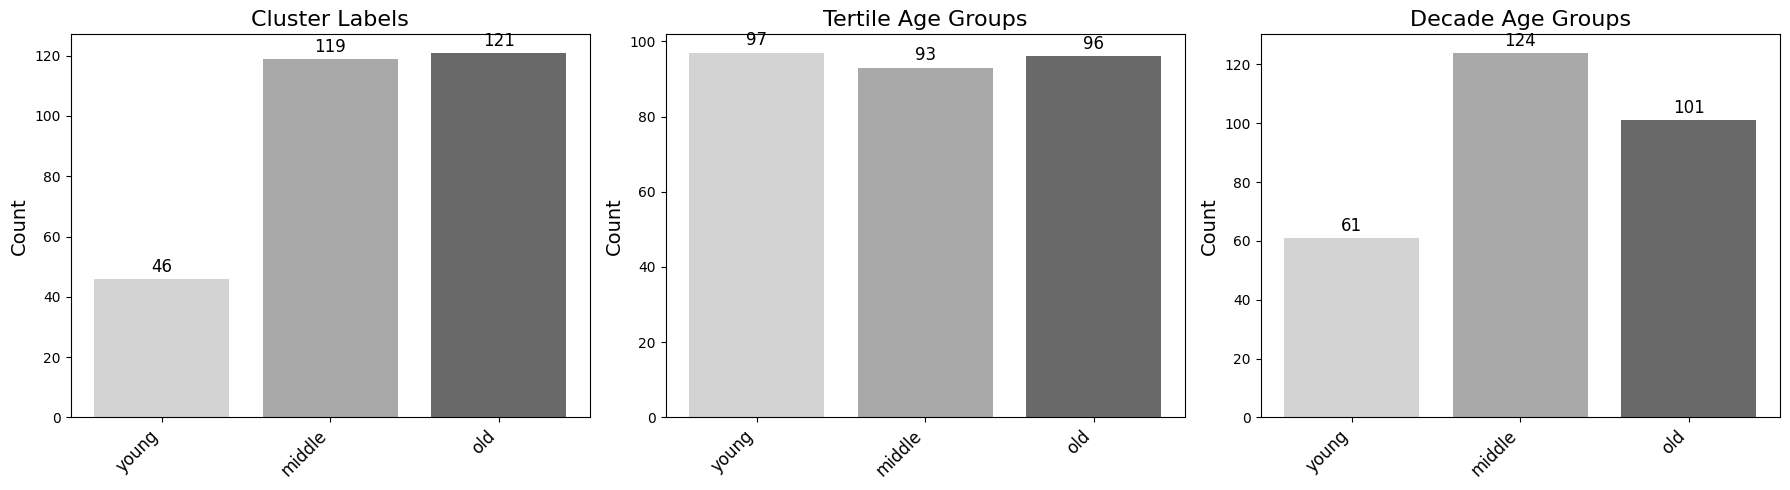

In [16]:
age_colors = {"young": "#D3D3D3", "middle": "#A9A9A9", "old": "#696969"}

# counters
counters = [
    Counter(age_df['cluster_label']),
    Counter(age_df['tertile_age_group']),
    Counter(age_df['decade_age_group'])
]

titles = ['Cluster Labels', 'Tertile Age Groups', 'Decade Age Groups']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, counter, title in zip(axes, counters, titles):
    keys = list(counter.keys())
    
    keys = ['young', 'middle', 'old']
    values = [counter.get(k, 0) for k in keys]
    colors = [age_colors[k] for k in keys]

    bars = ax.bar(keys, values, color=colors)
    
    # Show counts on top
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, value + 1, str(value),
                ha='center', va='bottom', fontsize=12)

    ax.set_title(title, fontsize=16)
    ax.set_ylabel("Count", fontsize=14)
    ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.savefig(plots_dir + "05_number_of_donors_based_on_aging_definitions.pdf")
plt.show()